In [ ]:
import os

def assign_ids_to_dataset(dataset_path, start_id=1000):
    """
    Renames each subfolder in 'dataset_path' to '<ID>_<originalFolderName>'.
    Returns a dictionary: { <ID>: "ID_OriginalName" }
    """
    if not os.path.isdir(dataset_path):
        raise ValueError(f"Dataset path does not exist: {dataset_path}")

    unique_id_map = {}
    current_id = start_id

    # List all subfolders
    folders = [f for f in os.listdir(dataset_path)
               if os.path.isdir(os.path.join(dataset_path, f))]

    for folder in sorted(folders):
        old_path = os.path.join(dataset_path, folder)
        new_folder_name = f"{current_id}_{folder}"
        new_path = os.path.join(dataset_path, new_folder_name)

        # Rename the folder
        os.rename(old_path, new_path)

        # Store mapping in dictionary
        unique_id_map[current_id] = new_folder_name
        print(f"Renamed '{folder}' -> '{new_folder_name}' (ID={current_id})")

        current_id += 1

    return unique_id_map

if __name__ == "__main__":
    # Example usage:
    dataset_path = r"C:\Users\muham\PycharmProjects\pythonProject\Verification\lfw_subset"
    mapping = assign_ids_to_dataset(dataset_path, start_id=1000)

    # You now have each folder named like "1000_Aaron_Tippin", "1001_Abba_Eban", etc.
    # mapping[1000] = "1000_Aaron_Tippin", etc.
    print("\nUnique ID assignment complete!")
    print("Mapping:", mapping)


In [3]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

"""
Author: Your Name
Date:   01/01/2025
Description:
  This script traverses a face dataset directory where each subfolder
  contains images of one person. It computes face embeddings (using DeepFace),
  then generates pairs:
    - same-person (label=1)
    - different-person (label=0)
  and calculates a distance (Euclidean) for each pair.

  Finally, it writes (distance, label) rows into 'results.csv'.

Usage:
  python generate_results_csv.py
"""

import os
import random
import csv
import numpy as np
from deepface import DeepFace

# 1) CONFIG - Modify as needed
DATASET_DIR = r"C:\Users\muham\PycharmProjects\pythonProject\Verification\lfw_subset"      # Path to your dataset root folder
RESULTS_CSV = "results.csv"  # Output CSV: (distance, label)
MODEL_NAME = "Facenet"       # or "VGG-Face", "ArcFace", "DeepFace", ...
ENFORCE_DETECTION = False    # True if you want face detection strictly enforced
MAX_SAME_PAIRS_PER_PERSON = 5
MAX_DIFF_PAIRS_PER_PERSON = 5


def get_embedding(img_path, model_name='Facenet'):
    """
    Computes face embedding for a single image using DeepFace.
    Returns a NumPy array (embedding) or None if it fails.
    """
    try:
        resp = DeepFace.represent(
            img_path=img_path,
            model_name=model_name,
            enforce_detection=ENFORCE_DETECTION
        )
        # 'resp' is typically a list of dicts if enforce_detection=False
        # e.g. [{'embedding': [...], 'facial_area': ..., ...}]
        if resp and len(resp) > 0:
            # Convert embedding (list) to NumPy array
            embedding_array = np.array(resp[0]['embedding'], dtype=np.float32)
            return embedding_array
    except Exception as e:
        print(f"Warning: embedding failed for {img_path}: {e}")

    return None


def euclidean_distance(emb1, emb2):
    """
    Computes Euclidean (L2) distance between two NumPy embedding arrays.
    """
    return np.linalg.norm(emb1 - emb2)


def main():
    # 2) GATHER EMBEDDINGS into a dictionary
    #    embeddings_dict[person_folder] = [emb_array1, emb_array2, ...]
    embeddings_dict = {}

    # List all subdirectories (persons)
    person_folders = [
        d for d in os.listdir(DATASET_DIR)
        if os.path.isdir(os.path.join(DATASET_DIR, d))
    ]

    for person in person_folders:
        folder_path = os.path.join(DATASET_DIR, person)
        embeddings = []
        for img_file in os.listdir(folder_path):
            if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                img_path = os.path.join(folder_path, img_file)
                emb = get_embedding(img_path, model_name=MODEL_NAME)
                if emb is not None:
                    embeddings.append(emb)

        if embeddings:
            embeddings_dict[person] = embeddings
        else:
            print(f"No valid embeddings found for person folder: {person}")

    persons_data = list(embeddings_dict.items())
    print(f"Found embeddings for {len(persons_data)} persons in '{DATASET_DIR}'.")

    # 3) BUILD PAIRS & COMPUTE DISTANCES
    results = []  # will hold tuples of (distance, label)

    # A) Genuine (same-person) pairs
    for person, emb_list in persons_data:
        if len(emb_list) < 2:
            continue  # need at least 2 embeddings to form a same-person pair

        same_pairs_count = 0
        all_indices = list(range(len(emb_list)))
        attempts = 0

        while same_pairs_count < MAX_SAME_PAIRS_PER_PERSON and attempts < 1000:
            i1, i2 = random.sample(all_indices, 2)
            emb1, emb2 = emb_list[i1], emb_list[i2]
            dist = euclidean_distance(emb1, emb2)
            results.append((dist, 1))  # label=1 => same-person
            same_pairs_count += 1
            attempts += 1

    # B) Imposter (different-person) pairs
    if len(persons_data) > 1:
        for idx, (personA, embA_list) in enumerate(persons_data):
            if len(embA_list) == 0:
                continue

            diff_pairs_count = 0
            attempts = 0

            while diff_pairs_count < MAX_DIFF_PAIRS_PER_PERSON and attempts < 1000:
                other_idx = random.randint(0, len(persons_data) - 1)
                if other_idx == idx:
                    attempts += 1
                    continue

                personB, embB_list = persons_data[other_idx]
                if len(embB_list) == 0:
                    attempts += 1
                    continue

                # pick random embedding from each person's list
                embA = random.choice(embA_list)
                embB = random.choice(embB_list)
                dist = euclidean_distance(embA, embB)
                results.append((dist, 0))  # label=0 => different-person
                diff_pairs_count += 1
                attempts += 1

    # 4) WRITE CSV
    with open(RESULTS_CSV, 'w', newline='') as f:
        writer = csv.writer(f)
        for dist, label in results:
            writer.writerow([dist, label])

    print(f"\nWrote {len(results)} pairs to '{RESULTS_CSV}'. Done.")


if __name__ == "__main__":
    main()


Found embeddings for 52 persons in 'C:\Users\muham\PycharmProjects\pythonProject\Verification\lfw_subset'.

Wrote 325 pairs to 'results.csv'. Done.


EER = 0.1077 at threshold=13.3294

Sample thresholds vs. FAR/FRR:
 threshold=5.062  FAR=0.000  FRR=1.000
 threshold=13.124  FAR=0.096  FRR=0.123
 threshold=15.461  FAR=0.300  FRR=0.000
 threshold=16.465  FAR=0.542  FRR=0.000
 threshold=17.345  FAR=0.769  FRR=0.000
 threshold=19.578  FAR=0.996  FRR=0.000


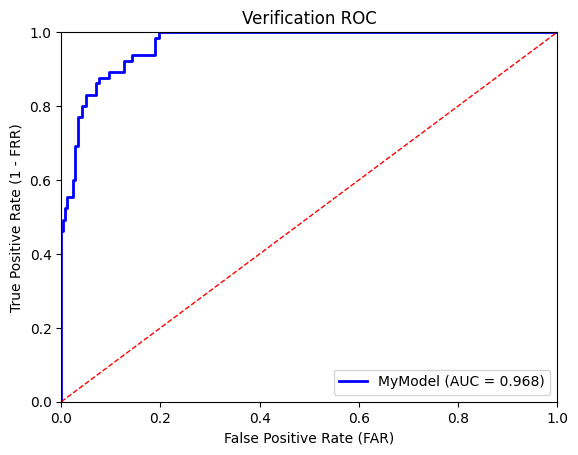

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import csv

# If you're in a Jupyter notebook, enable inline plots
# %matplotlib inline

def compute_far_frr(distances, labels):
    """
    Calculate FAR (False Acceptance Rate) and FRR (False Rejection Rate)
    for a range of thresholds derived from the 'distances'.

    distances: array-like of shape (N,)
    labels:    array-like of shape (N,) with values in {0, 1}
               1 = same-person (genuine), 0 = different-person (imposter)

    Returns:
        thresholds: np.array of unique distance values (sorted ascending)
        FAR:        np.array of false acceptance rates for each threshold
        FRR:        np.array of false rejection rates for each threshold
    """
    # Sort distances ascending
    sorted_distances = np.sort(distances)
    thresholds = np.unique(sorted_distances)

    FAR_list = []
    FRR_list = []

    # For each threshold: "predict same if distance < threshold"
    for th in thresholds:
        preds_same = distances < th

        # Among label=0 (imposters), how many are accepted? (false accepts)
        false_accepts = np.sum((preds_same == True) & (labels == 0))
        total_imposter = np.sum(labels == 0)
        if total_imposter > 0:
            far = false_accepts / float(total_imposter)
        else:
            far = 0.0

        # Among label=1 (genuines), how many are rejected? (false rejects)
        false_rejects = np.sum((preds_same == False) & (labels == 1))
        total_genuine = np.sum(labels == 1)
        if total_genuine > 0:
            frr = false_rejects / float(total_genuine)
        else:
            frr = 0.0

        FAR_list.append(far)
        FRR_list.append(frr)

    return thresholds, np.array(FAR_list), np.array(FRR_list)

def find_eer(far, frr, thresholds):
    """
    Find the Equal Error Rate (EER) where FAR and FRR intersect (or are closest).
    Returns (eer_value, threshold_at_eer).
    """
    diff = np.abs(far - frr)
    idx = np.argmin(diff)
    eer_value = (far[idx] + frr[idx]) / 2.0
    threshold_at_eer = thresholds[idx]
    return eer_value, threshold_at_eer

def plot_roc_curve(distances, labels, title='ROC Curve', model_name='Model'):
    """
    Plots the ROC curve (TPR vs FPR) using sklearn's roc_curve.
    distances: array-like (N,), smaller => more likely same
    labels:    array-like (N,), 1 => same-person, 0 => different-person
    """
    # Invert distances to produce a higher-is-better "score"
    scores = -distances  # or 1.0 - distances, whichever suits your scale

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'{model_name} (AUC = {roc_auc:.3f})')
    plt.plot([0,1], [0,1], color='red', linestyle='--', lw=1)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.xlabel('False Positive Rate (FAR)')
    plt.ylabel('True Positive Rate (1 - FRR)')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.show()

# -------------------------------------------------------------------------------
# Now we do the actual evaluation in one cell
# -------------------------------------------------------------------------------
# 1) Load CSV with columns: distance,label
csv_file = "results.csv"  # Adjust if needed

# If your file has no header and just two columns, we can do something like:
data = np.loadtxt(csv_file, delimiter=",")
distances = data[:, 0]
labels = data[:, 1].astype(int)

# 2) Compute thresholds, FAR, FRR
thresholds, FAR, FRR = compute_far_frr(distances, labels)

# 3) Find EER
eer_value, eer_threshold = find_eer(FAR, FRR, thresholds)
print(f"EER = {eer_value:.4f} at threshold={eer_threshold:.4f}")

# 4) (Optional) print some threshold-FAR-FRR
print("\nSample thresholds vs. FAR/FRR:")
step = max(1, len(thresholds) // 5)
for i in range(0, len(thresholds), step):
    print(f" threshold={thresholds[i]:.3f}  FAR={FAR[i]:.3f}  FRR={FRR[i]:.3f}")

# 5) Plot ROC curve
plot_roc_curve(distances, labels, title='Verification ROC', model_name='MyModel')


In [11]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

"""
Author: Your Name
Date:   01/01/2025
Description:
  This script traverses the same face dataset directory for two different
  DeepFace models (e.g., 'Facenet' and 'ArcFace'), computes embeddings,
  then generates pairs:
    - same-person (label=1)
    - different-person (label=0)
  and calculates a distance (Euclidean) for each model's embeddings.

  Finally, it writes two separate CSV files:
    results_model1.csv
    results_model2.csv

Usage:
  python generate_results_two_models.py
"""

import os
import random
import csv
import numpy as np
from deepface import DeepFace

# 1) CONFIG - Modify as needed
DATASET_DIR = r"C:\Users\muham\PycharmProjects\pythonProject\Verification\lfw_subset"
RESULTS_CSV_1 = "results_model1.csv"  # Output CSV for model1
RESULTS_CSV_2 = "results_model2.csv"  # Output CSV for model2

MODEL1_NAME = "Facenet"   # e.g. "VGG-Face", "ArcFace", "Facenet", ...
MODEL2_NAME = "VGG-Face"

ENFORCE_DETECTION = False
MAX_SAME_PAIRS_PER_PERSON = 5
MAX_DIFF_PAIRS_PER_PERSON = 5

def get_embedding(img_path, model_name='Facenet'):
    """
    Computes face embedding for a single image using DeepFace.
    Returns a NumPy array (embedding) or None if it fails.
    """
    try:
        resp = DeepFace.represent(
            img_path=img_path,
            model_name=model_name,
            enforce_detection=ENFORCE_DETECTION
        )
        if resp and len(resp) > 0:
            embedding_array = np.array(resp[0]['embedding'], dtype=np.float32)
            return embedding_array
    except Exception as e:
        print(f"[{model_name}] Warning: embedding failed for {img_path}: {e}")
    return None

def euclidean_distance(emb1, emb2):
    """Euclidean (L2) distance between two NumPy embedding arrays."""
    return np.linalg.norm(emb1 - emb2)

def main():
    # 2) GATHER EMBEDDINGS for both models in parallel
    #    embeddings_dict_1[person] = [emb1_model1, emb2_model1, ...]
    #    embeddings_dict_2[person] = [emb1_model2, emb2_model2, ...]
    embeddings_dict_1 = {}
    embeddings_dict_2 = {}

    person_folders = [
        d for d in os.listdir(DATASET_DIR)
        if os.path.isdir(os.path.join(DATASET_DIR, d))
    ]

    for person in person_folders:
        folder_path = os.path.join(DATASET_DIR, person)

        emb_list_1 = []
        emb_list_2 = []

        for img_file in os.listdir(folder_path):
            if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                img_path = os.path.join(folder_path, img_file)

                # Model1 embedding
                emb1 = get_embedding(img_path, model_name=MODEL1_NAME)
                # Model2 embedding
                emb2 = get_embedding(img_path, model_name=MODEL2_NAME)

                # We only keep embeddings if both are not None
                if emb1 is not None:
                    emb_list_1.append(emb1)
                if emb2 is not None:
                    emb_list_2.append(emb2)

        if emb_list_1:
            embeddings_dict_1[person] = emb_list_1
        if emb_list_2:
            embeddings_dict_2[person] = emb_list_2

    persons_data_1 = list(embeddings_dict_1.items())
    persons_data_2 = list(embeddings_dict_2.items())
    print(f"[Model1={MODEL1_NAME}] Found embeddings for {len(persons_data_1)} persons.")
    print(f"[Model2={MODEL2_NAME}] Found embeddings for {len(persons_data_2)} persons.")

    # 3) BUILD PAIRS & COMPUTE DISTANCES FOR EACH MODEL
    results_model1 = []  # (distance, label)
    results_model2 = []  # (distance, label)

    # A) Same-person pairs
    # We iterate over the same 'person_folders', but each model might not have data for that person.
    # So we match them by name if present in both embeddings_dict_1 and embeddings_dict_2,
    # but we also generate separate results if a person exists in only one dictionary.
    # For clarity, let's do them separately.

    # Model1
    for person, emb_list in persons_data_1:
        if len(emb_list) < 2:
            continue
        same_pairs_count = 0
        all_indices = list(range(len(emb_list)))
        attempts = 0

        while same_pairs_count < MAX_SAME_PAIRS_PER_PERSON and attempts < 1000:
            i1, i2 = random.sample(all_indices, 2)
            dist = euclidean_distance(emb_list[i1], emb_list[i2])
            results_model1.append((dist, 1))
            same_pairs_count += 1
            attempts += 1

    # Model2
    for person, emb_list in persons_data_2:
        if len(emb_list) < 2:
            continue
        same_pairs_count = 0
        all_indices = list(range(len(emb_list)))
        attempts = 0

        while same_pairs_count < MAX_SAME_PAIRS_PER_PERSON and attempts < 1000:
            i1, i2 = random.sample(all_indices, 2)
            dist = euclidean_distance(emb_list[i1], emb_list[i2])
            results_model2.append((dist, 1))
            same_pairs_count += 1
            attempts += 1

    # B) Different-person (imposter) pairs
    # Model1
    if len(persons_data_1) > 1:
        for idx, (personA, embA_list) in enumerate(persons_data_1):
            diff_pairs_count = 0
            attempts = 0
            while diff_pairs_count < MAX_DIFF_PAIRS_PER_PERSON and attempts < 1000:
                other_idx = random.randint(0, len(persons_data_1) - 1)
                if other_idx == idx:
                    attempts += 1
                    continue

                personB, embB_list = persons_data_1[other_idx]
                if len(embA_list) == 0 or len(embB_list) == 0:
                    attempts += 1
                    continue

                embA = random.choice(embA_list)
                embB = random.choice(embB_list)
                dist = euclidean_distance(embA, embB)
                results_model1.append((dist, 0))
                diff_pairs_count += 1
                attempts += 1

    # Model2
    if len(persons_data_2) > 1:
        for idx, (personA, embA_list) in enumerate(persons_data_2):
            diff_pairs_count = 0
            attempts = 0
            while diff_pairs_count < MAX_DIFF_PAIRS_PER_PERSON and attempts < 1000:
                other_idx = random.randint(0, len(persons_data_2) - 1)
                if other_idx == idx:
                    attempts += 1
                    continue

                personB, embB_list = persons_data_2[other_idx]
                if len(embA_list) == 0 or len(embB_list) == 0:
                    attempts += 1
                    continue

                embA = random.choice(embA_list)
                embB = random.choice(embB_list)
                dist = euclidean_distance(embA, embB)
                results_model2.append((dist, 0))
                diff_pairs_count += 1
                attempts += 1

    # 4) WRITE TO CSV
    with open(RESULTS_CSV_1, 'w', newline='') as f1:
        writer1 = csv.writer(f1)
        for dist, label in results_model1:
            writer1.writerow([dist, label])

    with open(RESULTS_CSV_2, 'w', newline='') as f2:
        writer2 = csv.writer(f2)
        for dist, label in results_model2:
            writer2.writerow([dist, label])

    print(f"\nModel1: Wrote {len(results_model1)} pairs to '{RESULTS_CSV_1}'.")
    print(f"Model2: Wrote {len(results_model2)} pairs to '{RESULTS_CSV_2}'.")
    print("Done.")

if __name__ == "__main__":
    main()


[Model1=Facenet] Found embeddings for 52 persons.
[Model2=VGG-Face] Found embeddings for 52 persons.

Model1: Wrote 325 pairs to 'results_model1.csv'.
Model2: Wrote 325 pairs to 'results_model2.csv'.
Done.


Model1 (Facenet): EER=0.063, threshold=12.818
Model2 (VGG-Face): EER=0.154, threshold=1.302


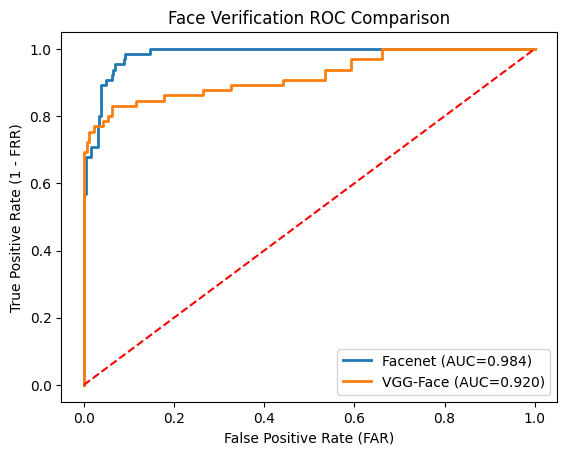

In [12]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

"""
Evaluate and compare two face verification models
that have each produced a CSV of (distance, label) pairs.

We load:
  results_model1.csv
  results_model2.csv
Compute:
  - FAR, FRR, EER
  - Plot two ROC curves together
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Modify as needed:
RESULTS_MODEL1 = "results_model1.csv"
RESULTS_MODEL2 = "results_model2.csv"
MODEL1_NAME = "Facenet"
MODEL2_NAME = "VGG-Face"

def compute_far_frr(distances, labels):
    sorted_dist = np.sort(distances)
    thresholds = np.unique(sorted_dist)

    FAR, FRR = [], []
    for th in thresholds:
        preds_same = distances < th

        false_accepts = np.sum((preds_same == True) & (labels == 0))
        total_imposter = np.sum(labels == 0)
        far = false_accepts / total_imposter if total_imposter > 0 else 0

        false_rejects = np.sum((preds_same == False) & (labels == 1))
        total_genuine = np.sum(labels == 1)
        frr = false_rejects / total_genuine if total_genuine > 0 else 0

        FAR.append(far)
        FRR.append(frr)

    return thresholds, np.array(FAR), np.array(FRR)

def find_eer(far, frr, thresholds):
    diff = np.abs(far - frr)
    idx = np.argmin(diff)
    eer_value = (far[idx] + frr[idx]) / 2.0
    eer_th = thresholds[idx]
    return eer_value, eer_th

def plot_roc(distances, labels, model_name='Model'):
    # invert distance => scores
    scores = -distances
    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC={roc_auc:.3f})')

def main():
    # Load results for Model1
    data1 = np.loadtxt(RESULTS_MODEL1, delimiter=",")
    dist1 = data1[:, 0]
    labels1 = data1[:, 1].astype(int)

    # Evaluate Model1
    th1, FAR1, FRR1 = compute_far_frr(dist1, labels1)
    eer1, th_eer1 = find_eer(FAR1, FRR1, th1)
    print(f"Model1 ({MODEL1_NAME}): EER={eer1:.3f}, threshold={th_eer1:.3f}")

    # Load results for Model2
    data2 = np.loadtxt(RESULTS_MODEL2, delimiter=",")
    dist2 = data2[:, 0]
    labels2 = data2[:, 1].astype(int)

    # Evaluate Model2
    th2, FAR2, FRR2 = compute_far_frr(dist2, labels2)
    eer2, th_eer2 = find_eer(FAR2, FRR2, th2)
    print(f"Model2 ({MODEL2_NAME}): EER={eer2:.3f}, threshold={th_eer2:.3f}")

    # Plot combined ROC
    plt.figure()
    plot_roc(dist1, labels1, model_name=MODEL1_NAME)
    plot_roc(dist2, labels2, model_name=MODEL2_NAME)
    plt.plot([0,1], [0,1], color='red', linestyle='--')
    plt.xlabel('False Positive Rate (FAR)')
    plt.ylabel('True Positive Rate (1 - FRR)')
    plt.title("Face Verification ROC Comparison")
    plt.legend(loc='lower right')
    plt.show()

if __name__ == "__main__":
    main()


Evaluating Model 1...


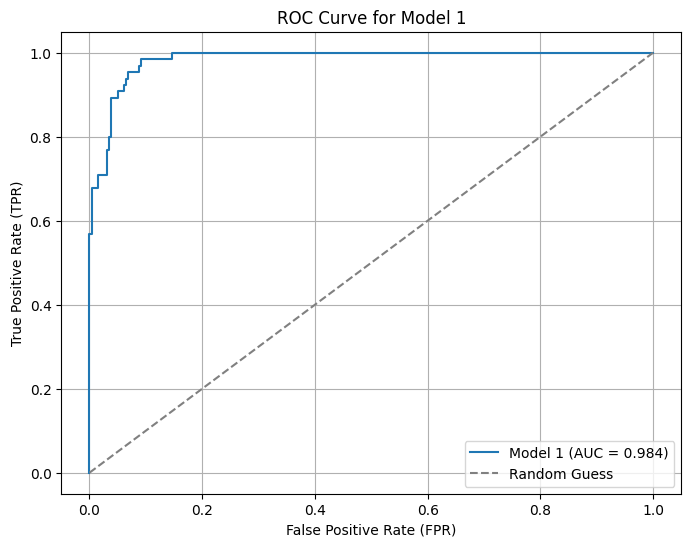

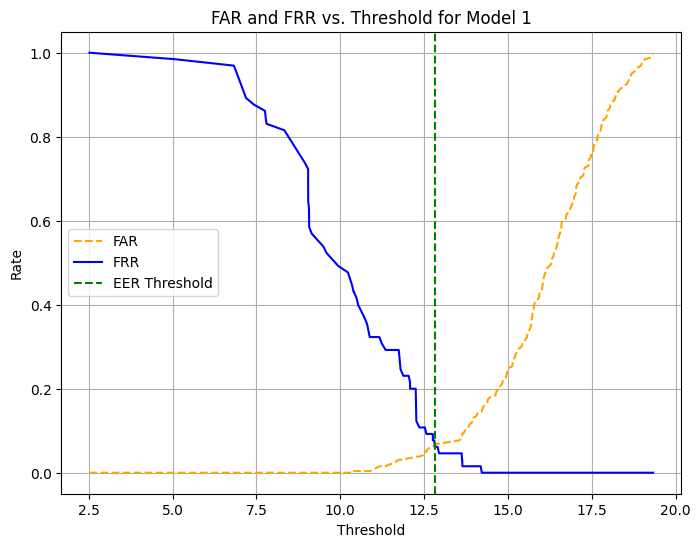

Model 1: EER = 0.063 at Threshold = 12.818

Evaluating Model 2...


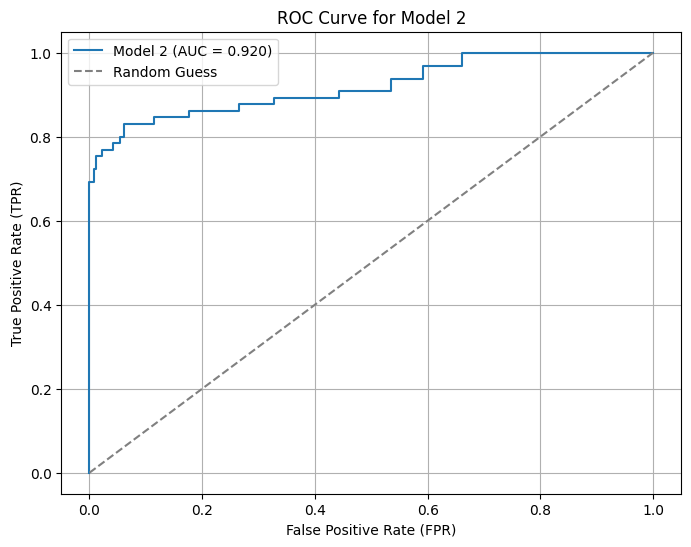

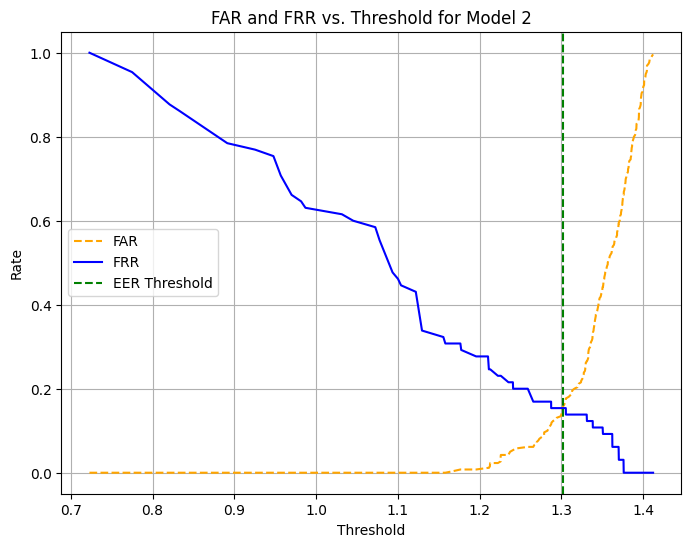

Model 2: EER = 0.154 at Threshold = 1.302


In [29]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def compute_far_frr(distances, labels):
    """
    Calculate FAR (False Acceptance Rate) and FRR (False Rejection Rate)
    for a range of thresholds derived from the distances.
    """
    thresholds = np.unique(np.sort(distances))
    FAR_list, FRR_list = [], []

    for th in thresholds:
        preds_same = distances < th
        false_accepts = np.sum((preds_same == True) & (labels == 0))
        total_imposters = np.sum(labels == 0)
        far = false_accepts / total_imposters if total_imposters > 0 else 0.0

        false_rejects = np.sum((preds_same == False) & (labels == 1))
        total_genuine = np.sum(labels == 1)
        frr = false_rejects / total_genuine if total_genuine > 0 else 0.0

        FAR_list.append(far)
        FRR_list.append(frr)

    return thresholds, np.array(FAR_list), np.array(FRR_list)

def find_eer(far, frr, thresholds):
    """
    Find the Equal Error Rate (EER) where FAR and FRR intersect (or are closest).
    """
    diff = np.abs(far - frr)
    idx = np.argmin(diff)
    eer_value = (far[idx] + frr[idx]) / 2.0
    threshold_at_eer = thresholds[idx]
    return eer_value, threshold_at_eer

def plot_roc_curve(distances, labels, model_name):
    """
    Plots the ROC curve (TPR vs FPR) for a given model.
    """
    scores = -distances
    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
    plt.title(f"ROC Curve for {model_name}")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_far_frr(thresholds, FAR, FRR, model_name):
    """
    Plots FAR and FRR as a function of the threshold for a given model.
    """
    plt.figure(figsize=(8, 6))
    plt.plot(thresholds, FAR, label='FAR', linestyle='--', color='orange')
    plt.plot(thresholds, FRR, label='FRR', linestyle='-', color='blue')
    plt.axvline(x=thresholds[np.argmin(np.abs(FAR - FRR))], linestyle='--', color='green', label='EER Threshold')
    plt.title(f"FAR and FRR vs. Threshold for {model_name}")
    plt.xlabel("Threshold")
    plt.ylabel("Rate")
    plt.legend()
    plt.grid(True)
    plt.show()

def evaluate_model(csv_file, model_name):
    """
    Evaluate a model's performance based on a results CSV file.
    """
    data = np.loadtxt(csv_file, delimiter=",")
    distances = data[:, 0]
    labels = data[:, 1].astype(int)

    thresholds, FAR, FRR = compute_far_frr(distances, labels)
    eer_value, eer_threshold = find_eer(FAR, FRR, thresholds)

    # Plot each metric separately
    plot_roc_curve(distances, labels, model_name)
    plot_far_frr(thresholds, FAR, FRR, model_name)

    return eer_value, eer_threshold

# ----------------------------------------------------------------------
# Main Execution: Compare Models
# ----------------------------------------------------------------------
if __name__ == "__main__":
    model1_csv = "results_model1.csv"  # Replace with your file path
    model2_csv = "results_model2.csv"  # Replace with your file path

    print("Evaluating Model 1...")
    eer1, th1 = evaluate_model(model1_csv, model_name="Model 1")
    print(f"Model 1: EER = {eer1:.3f} at Threshold = {th1:.3f}")

    print("\nEvaluating Model 2...")
    eer2, th2 = evaluate_model(model2_csv, model_name="Model 2")
    print(f"Model 2: EER = {eer2:.3f} at Threshold = {th2:.3f}")


Evaluating Facenet...


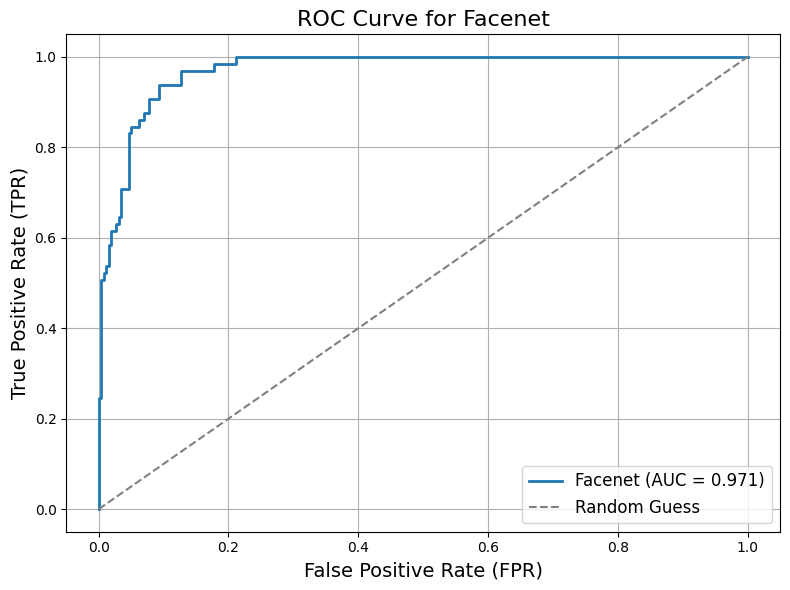

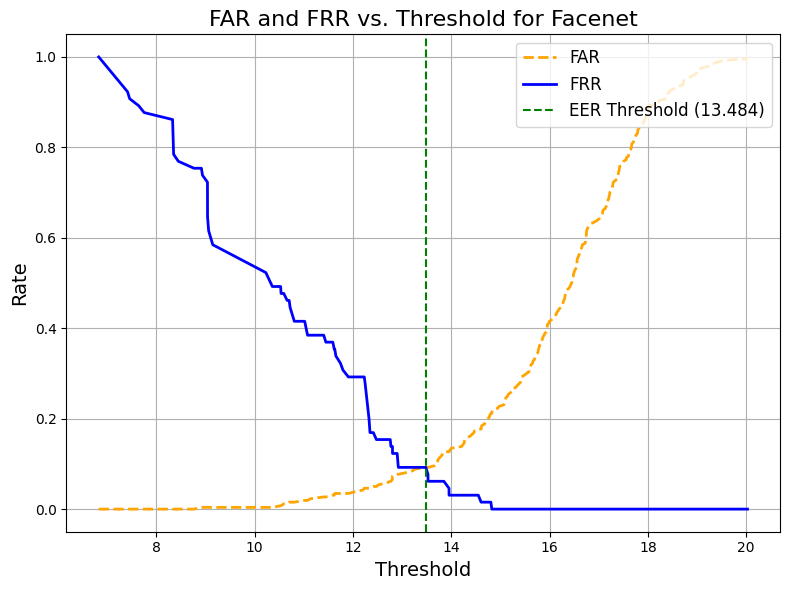

Facenet: EER = 0.092 at Threshold = 13.484

Evaluating VGG-Face...


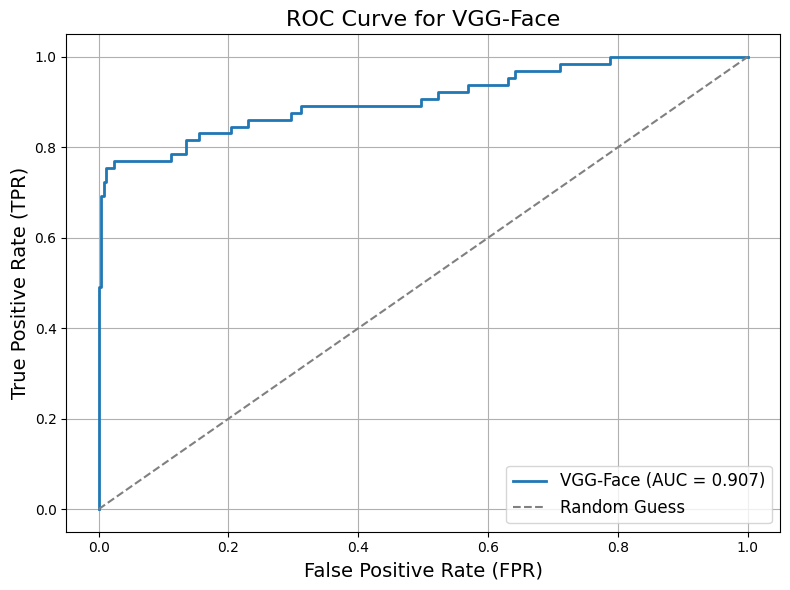

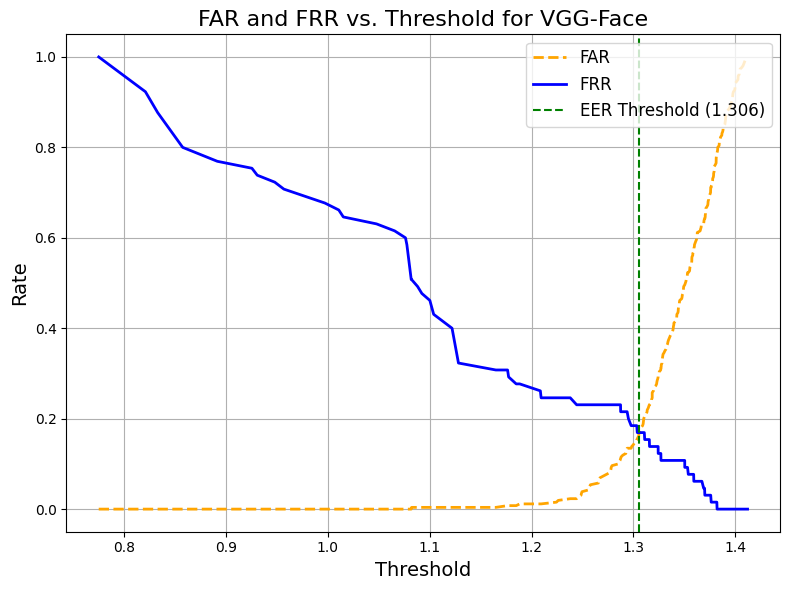

VGG-Face: EER = 0.169 at Threshold = 1.306


In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def compute_far_frr(distances, labels):
    """
    Calculate FAR (False Acceptance Rate) and FRR (False Rejection Rate)
    for a range of thresholds derived from the distances.
    """
    thresholds = np.unique(np.sort(distances))
    FAR_list, FRR_list = [], []

    for th in thresholds:
        preds_same = distances < th
        false_accepts = np.sum((preds_same == True) & (labels == 0))
        total_imposters = np.sum(labels == 0)
        far = false_accepts / total_imposters if total_imposters > 0 else 0.0

        false_rejects = np.sum((preds_same == False) & (labels == 1))
        total_genuine = np.sum(labels == 1)
        frr = false_rejects / total_genuine if total_genuine > 0 else 0.0

        FAR_list.append(far)
        FRR_list.append(frr)

    return thresholds, np.array(FAR_list), np.array(FRR_list)

def find_eer(far, frr, thresholds):
    """
    Find the Equal Error Rate (EER) where FAR and FRR intersect (or are closest).
    """
    diff = np.abs(far - frr)
    idx = np.argmin(diff)
    eer_value = (far[idx] + frr[idx]) / 2.0
    threshold_at_eer = thresholds[idx]
    return eer_value, threshold_at_eer

def plot_roc_curve(distances, labels, model_name):
    """
    Plots the ROC curve (TPR vs FPR) for a given model.
    """
    scores = -distances  # Assuming lower distances mean higher similarity
    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.3f})', linewidth=2)
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
    plt.title(f"ROC Curve for {model_name}", fontsize=16)
    plt.xlabel("False Positive Rate (FPR)", fontsize=14)
    plt.ylabel("True Positive Rate (TPR)", fontsize=14)
    plt.legend(loc='lower right', fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_far_frr(thresholds, FAR, FRR, model_name):
    """
    Plots FAR and FRR as a function of the threshold for a given model.
    """
    plt.figure(figsize=(8, 6))
    plt.plot(thresholds, FAR, label='FAR', linestyle='--', color='orange', linewidth=2)
    plt.plot(thresholds, FRR, label='FRR', linestyle='-', color='blue', linewidth=2)

    # Find EER threshold
    eer_idx = np.argmin(np.abs(FAR - FRR))
    eer_threshold = thresholds[eer_idx]
    eer_value = (FAR[eer_idx] + FRR[eer_idx]) / 2.0
    plt.axvline(x=eer_threshold, linestyle='--', color='green', label=f'EER Threshold ({eer_threshold:.3f})')

    plt.title(f"FAR and FRR vs. Threshold for {model_name}", fontsize=16)
    plt.xlabel("Threshold", fontsize=14)
    plt.ylabel("Rate", fontsize=14)
    plt.legend(loc='upper right', fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def evaluate_model(csv_file, model_name):
    """
    Evaluate a model's performance based on a results CSV file.

    The CSV file should have two columns:
    - Column 1: Distance scores
    - Column 2: Labels (1 for genuine, 0 for imposter)
    """
    # Load data
    try:
        data = np.loadtxt(csv_file, delimiter=",")
        distances = data[:, 0]
        labels = data[:, 1].astype(int)
    except Exception as e:
        print(f"Error loading {csv_file}: {e}")
        return None, None

    # Compute FAR, FRR
    thresholds, FAR, FRR = compute_far_frr(distances, labels)

    # Find EER
    eer_value, eer_threshold = find_eer(FAR, FRR, thresholds)

    # Plot ROC Curve
    plot_roc_curve(distances, labels, model_name)

    # Plot FAR and FRR
    plot_far_frr(thresholds, FAR, FRR, model_name)

    return eer_value, eer_threshold

# ----------------------------------------------------------------------
# Main Execution: Compare Models
# ----------------------------------------------------------------------
if __name__ == "__main__":
    # Define your result CSV files and corresponding model names
    RESULTS_MODEL1 = "results_model1.csv"  # Replace with your actual file path
    RESULTS_MODEL2 = "results_model2.csv"  # Replace with your actual file path
    MODEL1_NAME = "Facenet"
    MODEL2_NAME = "VGG-Face"

    # Evaluate Model 1
    print(f"Evaluating {MODEL1_NAME}...")
    eer1, th1 = evaluate_model(RESULTS_MODEL1, model_name=MODEL1_NAME)
    if eer1 is not None:
        print(f"{MODEL1_NAME}: EER = {eer1:.3f} at Threshold = {th1:.3f}")

    # Evaluate Model 2
    print(f"\nEvaluating {MODEL2_NAME}...")
    eer2, th2 = evaluate_model(RESULTS_MODEL2, model_name=MODEL2_NAME)
    if eer2 is not None:
        print(f"{MODEL2_NAME}: EER = {eer2:.3f} at Threshold = {th2:.3f}")


Evaluating Facenet...
Facenet: EER = 0.092 at Threshold = 13.484
Evaluating VGG-Face...
VGG-Face: EER = 0.169 at Threshold = 1.306


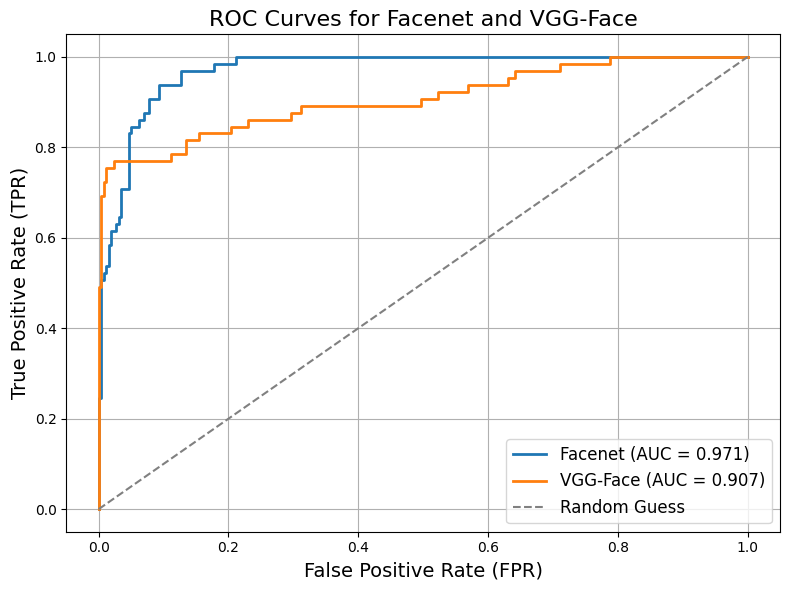

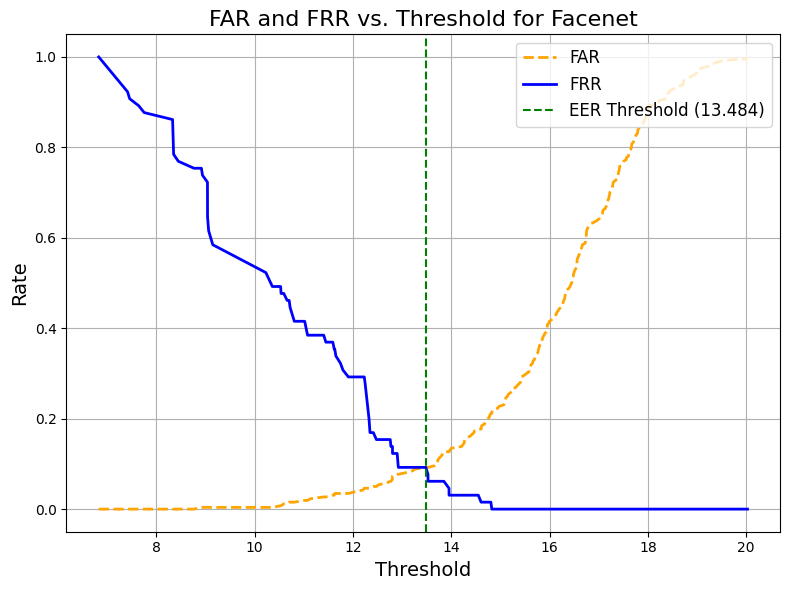

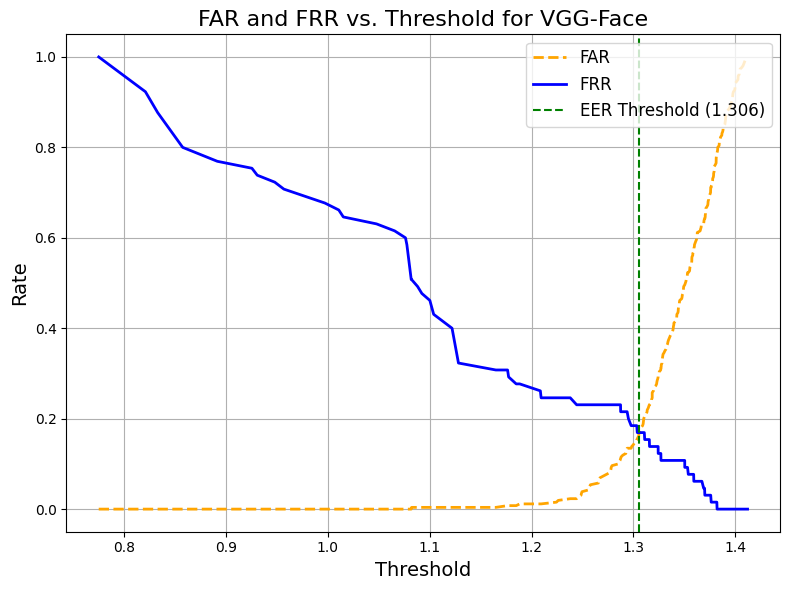

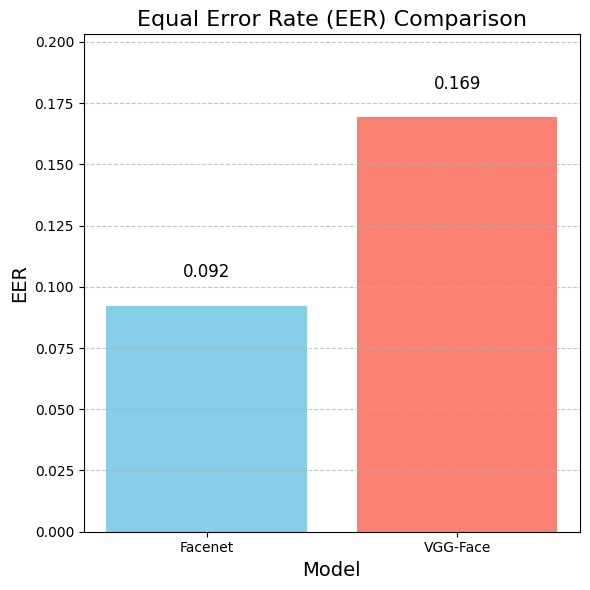

In [3]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import pandas as pd

def compute_far_frr(distances, labels):
    """
    Calculate FAR (False Acceptance Rate) and FRR (False Rejection Rate)
    for a range of thresholds derived from the distances.
    """
    thresholds = np.unique(np.sort(distances))
    FAR_list, FRR_list = [], []

    for th in thresholds:
        preds_same = distances < th
        false_accepts = np.sum((preds_same == True) & (labels == 0))
        total_imposters = np.sum(labels == 0)
        far = false_accepts / total_imposters if total_imposters > 0 else 0.0

        false_rejects = np.sum((preds_same == False) & (labels == 1))
        total_genuine = np.sum(labels == 1)
        frr = false_rejects / total_genuine if total_genuine > 0 else 0.0

        FAR_list.append(far)
        FRR_list.append(frr)

    return thresholds, np.array(FAR_list), np.array(FRR_list)

def find_eer(far, frr, thresholds):
    """
    Find the Equal Error Rate (EER) where FAR and FRR intersect (or are closest).
    """
    diff = np.abs(far - frr)
    idx = np.argmin(diff)
    eer_value = (far[idx] + frr[idx]) / 2.0
    threshold_at_eer = thresholds[idx]
    return eer_value, threshold_at_eer

def get_roc_data(distances, labels):
    """
    Compute ROC curve data.
    """
    scores = -distances  # Assuming lower distances mean higher similarity
    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc

def plot_roc_curves(roc_data_list, model_names):
    """
    Plots multiple ROC curves on a single graph.

    Parameters:
    - roc_data_list: List of tuples (fpr, tpr, roc_auc)
    - model_names: List of model names corresponding to roc_data_list
    """
    plt.figure(figsize=(8, 6))

    for (fpr, tpr, roc_auc), model_name in zip(roc_data_list, model_names):
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.3f})', linewidth=2)

    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
    plt.title("ROC Curves for Facenet and VGG-Face", fontsize=16)
    plt.xlabel("False Positive Rate (FPR)", fontsize=14)
    plt.ylabel("True Positive Rate (TPR)", fontsize=14)
    plt.legend(loc='lower right', fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_far_frr(thresholds_list, FAR_list, FRR_list, model_names):
    """
    Plots FAR and FRR curves for multiple models on separate plots.

    Parameters:
    - thresholds_list: List of threshold arrays for each model
    - FAR_list: List of FAR arrays for each model
    - FRR_list: List of FRR arrays for each model
    - model_names: List of model names corresponding to the above lists
    """
    for thresholds, FAR, FRR, model_name in zip(thresholds_list, FAR_list, FRR_list, model_names):
        plt.figure(figsize=(8, 6))
        plt.plot(thresholds, FAR, label='FAR', linestyle='--', color='orange', linewidth=2)
        plt.plot(thresholds, FRR, label='FRR', linestyle='-', color='blue', linewidth=2)

        # Find EER threshold
        eer_idx = np.argmin(np.abs(FAR - FRR))
        eer_threshold = thresholds[eer_idx]
        eer_value = (FAR[eer_idx] + FRR[eer_idx]) / 2.0
        plt.axvline(x=eer_threshold, linestyle='--', color='green', label=f'EER Threshold ({eer_threshold:.3f})')

        plt.title(f"FAR and FRR vs. Threshold for {model_name}", fontsize=16)
        plt.xlabel("Threshold", fontsize=14)
        plt.ylabel("Rate", fontsize=14)
        plt.legend(loc='upper right', fontsize=12)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

def plot_eer_bar(eer1, eer2, model1_name, model2_name):
    """
    Plots a bar chart comparing the Equal Error Rates (EER) of two models.
    """
    models = [model1_name, model2_name]
    eers = [eer1, eer2]

    plt.figure(figsize=(6, 6))
    bars = plt.bar(models, eers, color=['skyblue', 'salmon'])
    plt.title("Equal Error Rate (EER) Comparison", fontsize=16)
    plt.xlabel("Model", fontsize=14)
    plt.ylabel("EER", fontsize=14)
    plt.ylim([0, max(eers)*1.2])

    # Annotate bars with EER values
    for bar, eer in zip(bars, eers):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{eer:.3f}', ha='center', va='bottom', fontsize=12)

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def evaluate_model(csv_file, model_name):
    """
    Evaluate a model's performance based on a results CSV file.

    The CSV file should have two columns:
    - Column 1: Distance scores
    - Column 2: Labels (1 for genuine, 0 for imposter)
    """
    # Load data
    try:
        data = np.loadtxt(csv_file, delimiter=",")
        distances = data[:, 0]
        labels = data[:, 1].astype(int)
    except Exception as e:
        print(f"Error loading {csv_file}: {e}")
        return None, None, None, None, None, None, None, None

    # Compute FAR, FRR
    thresholds, FAR, FRR = compute_far_frr(distances, labels)

    # Find EER
    eer_value, eer_threshold = find_eer(FAR, FRR, thresholds)

    # Compute ROC data
    fpr, tpr, roc_auc = get_roc_data(distances, labels)

    return thresholds, FAR, FRR, fpr, tpr, roc_auc, eer_value, eer_threshold

# ----------------------------------------------------------------------
# Main Execution: Compare Models
# ----------------------------------------------------------------------
if __name__ == "__main__":
    # Define your result CSV files and corresponding model names
    RESULTS_MODEL1 = "results_model1.csv"  # Replace with your actual file path
    RESULTS_MODEL2 = "results_model2.csv"  # Replace with your actual file path
    MODEL1_NAME = "Facenet"
    MODEL2_NAME = "VGG-Face"

    model_names = [MODEL1_NAME, MODEL2_NAME]
    results_files = [RESULTS_MODEL1, RESULTS_MODEL2]

    thresholds_list = []
    FAR_list = []
    FRR_list = []
    roc_data_list = []
    eer_values = []
    eer_thresholds = []

    for csv_file, model_name in zip(results_files, model_names):
        print(f"Evaluating {model_name}...")
        eval_results = evaluate_model(csv_file, model_name)
        if eval_results[0] is not None:
            thresholds, FAR, FRR, fpr, tpr, roc_auc, eer, th_eer = eval_results
            thresholds_list.append(thresholds)
            FAR_list.append(FAR)
            FRR_list.append(FRR)
            roc_data_list.append((fpr, tpr, roc_auc))
            eer_values.append(eer)
            eer_thresholds.append(th_eer)
            print(f"{model_name}: EER = {eer:.3f} at Threshold = {th_eer:.3f}")
        else:
            print(f"{model_name}: Evaluation failed.")

    # Plot ROC curves for both models on a single graph
    plot_roc_curves(roc_data_list, model_names)

    # Plot FAR and FRR for both models separately
    plot_far_frr(thresholds_list, FAR_list, FRR_list, model_names)

    # Plot EER comparison
    plot_eer_bar(eer_values[0], eer_values[1], model_names[0], model_names[1])
